In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
def create_dataset(samples, features, label_noise, feature_noise_ratio):

    informative = int(features * (1 - feature_noise_ratio) * 0.5)
    redundant   = int(features * (1 - feature_noise_ratio) * 0.5)
    useless     = features - informative - redundant

    X, y = make_classification(
        n_samples=samples,
        n_features=informative + redundant,
        n_informative=informative,
        n_redundant=redundant,
        n_classes=2,
        flip_y=label_noise,
        class_sep=0.7,
        random_state=42
    )

    if useless > 0:
        noise_features = np.random.normal(0, 1, size=(samples, useless))
        X = np.hstack([X, noise_features])

    return X, y

In [4]:
label_noises = [0.0, 0.1, 0.2, 0.3]
feature_noises = [0.0, 0.3, 0.6]
sizes = [500, 2000, 10000, 50000]
dims = [50]

In [5]:
def svm_model(X, y, random_state):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return f1_score(y_test, pred), accuracy_score(y_test, pred)

In [6]:
def logistic_model(X, y, random_state):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return f1_score(y_test, pred), accuracy_score(y_test, pred)

In [7]:
def rf_model(X, y, random_state):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    model = RandomForestClassifier(n_estimators=150, random_state=random_state)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return f1_score(y_test, pred), accuracy_score(y_test, pred)

In [8]:
def evaluate(model_func, X, y, repeats=5):
    f1s, accs = [], []
    for seed in range(repeats):
        f1, acc = model_func(X, y, seed)
        f1s.append(f1)
        accs.append(acc)
    return np.mean(f1s), np.mean(accs)

In [9]:
records = []

for s in sizes:
    for d in dims:
        for ln in label_noises:
            for fn in feature_noises:

                X, y = create_dataset(s, d, ln, fn)

                svm_f1, svm_acc = evaluate(svm_model, X, y)
                lr_f1, lr_acc   = evaluate(logistic_model, X, y)
                rf_f1, rf_acc   = evaluate(rf_model, X, y)

                records.append([
                    s, d, int(ln*100), int(fn*100),
                    svm_acc, lr_acc, rf_acc,
                    svm_f1, lr_f1, rf_f1
                ])


columns = [
    "size","dimension","label_noise","feature_noise",
    "svm_acc","lr_acc","rf_acc",
    "svm_f1","lr_f1","rf_f1"
]

In [11]:
df = pd.DataFrame(records, columns=columns)
print(df.head())

   size  dimension  label_noise  feature_noise  svm_acc  lr_acc  rf_acc  \
0   500         50            0              0   0.8672  0.7312  0.7952   
1   500         50            0             30   0.8304  0.6480  0.8064   
2   500         50            0             60   0.7744  0.7104  0.8112   
3   500         50           10              0   0.8528  0.7168  0.7616   
4   500         50           10             30   0.7936  0.6784  0.7712   

     svm_f1     lr_f1     rf_f1  
0  0.872688  0.741043  0.798501  
1  0.826981  0.656037  0.803904  
2  0.774170  0.710305  0.808660  
3  0.858963  0.715351  0.764206  
4  0.791151  0.688985  0.777790  


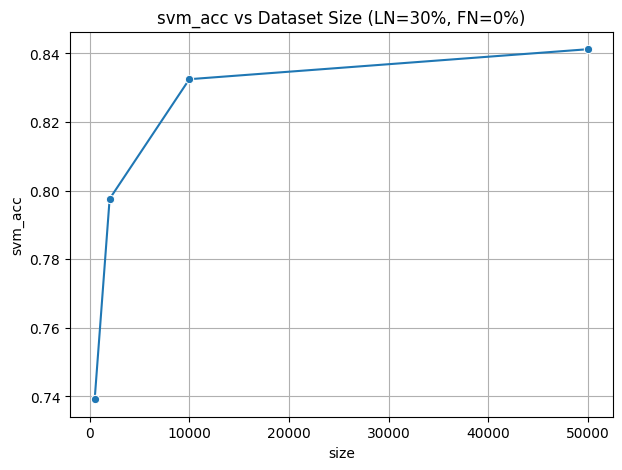

In [12]:
# plots

def plot_size_vs_accuracy(df, model="svm_acc", ln=30, fn=0):
    subset = df[(df.label_noise==ln) & (df.feature_noise==fn)]
    subset = subset.sort_values("size")

    plt.figure(figsize=(7,5))
    sns.lineplot(data=subset, x="size", y=model, marker="o")
    plt.title(f"{model} vs Dataset Size (LN={ln}%, FN={fn}%)")
    plt.grid()
    plt.show()

plot_size_vs_accuracy(df, "svm_acc", ln=30, fn=0)

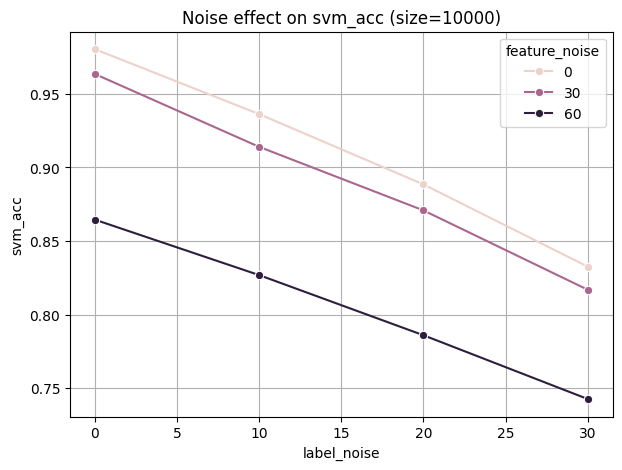

In [13]:
# Label vs Feature noise comparison

def plot_noise_comparison(df, model="svm_acc", size=10000):
    subset = df[df["size"]==size]

    plt.figure(figsize=(7,5))
    sns.lineplot(data=subset, x="label_noise", y=model, hue="feature_noise", marker="o")
    plt.title(f"Noise effect on {model} (size={size})")
    plt.grid()
    plt.show()

plot_noise_comparison(df, "svm_acc", size=10000)


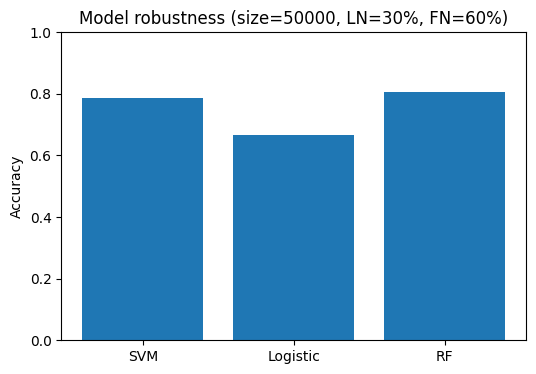

In [19]:
# Model robustness comparison

def plot_model_comparison(df, size=50000, ln=30, fn=60):

    subset = df[
        (df["size"] == size) &
        (df["label_noise"].round(0) == ln) &
        (df["feature_noise"].round(0) == fn)
    ]

    if subset.empty:
        print("No matching row found. Available combinations:")
        print(df[["size","label_noise","feature_noise"]].drop_duplicates())
        return

    values = subset[["svm_acc","lr_acc","rf_acc"]].iloc[0]

    plt.figure(figsize=(6,4))
    plt.bar(["SVM","Logistic","RF"], values)
    plt.title(f"Model robustness (size={size}, LN={ln}%, FN={fn}%)")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.show()


plot_model_comparison(df)

In [20]:
import pickle

df.to_pickle("results.pkl")
print("Results saved")


Results saved
